In [1]:
import numpy as np

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

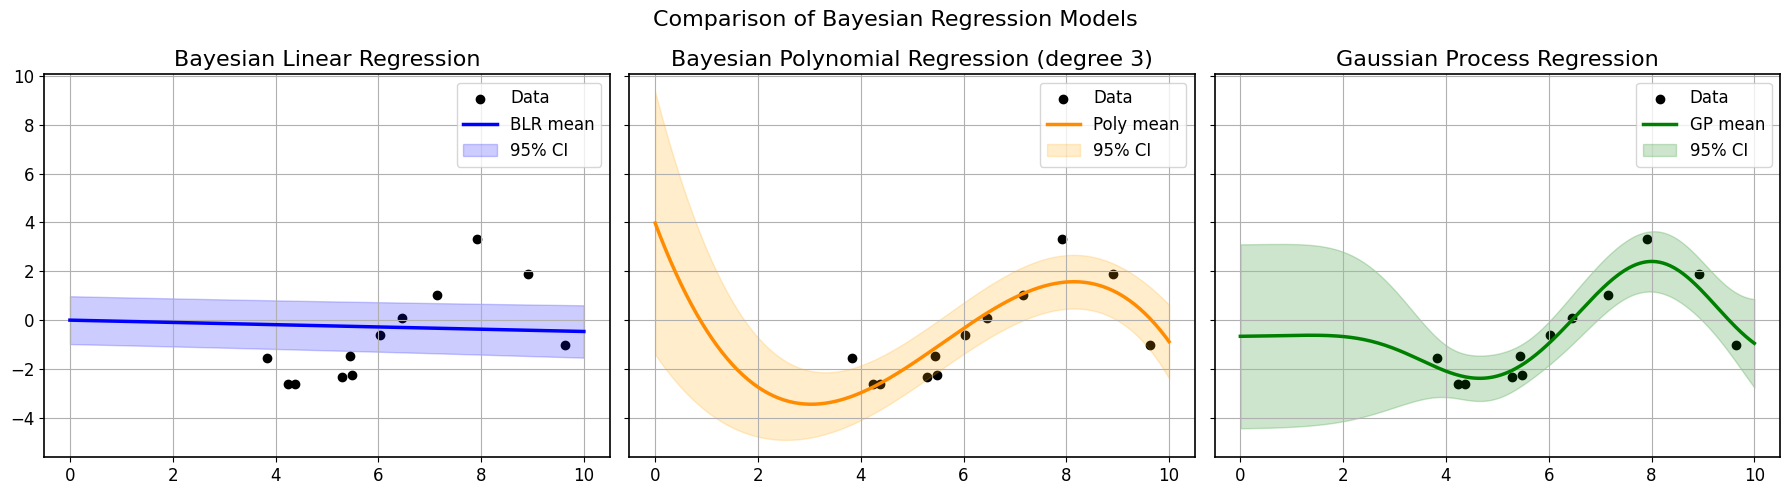

In [4]:
# Simulate data
np.random.seed(0)
n = 12
x = np.sort(np.random.uniform(0, 10, size=n))
true_func = lambda x: 3 * np.sin(x)
noise_std = 0.5
y = true_func(x) + np.random.normal(0, noise_std, size=n)

# Grid for prediction
x_pred = np.linspace(0, 10, 300)
X_pred = x_pred[:, None]
X = x[:, None]
sigma2 = noise_std**2

# ---------- Bayesian Linear Regression (no intercept) ----------
tau2_blr = 10.0
Sxx = np.sum(x**2)
Sxy = np.sum(x * y)
posterior_var_blr = 1 / (1 / tau2_blr + Sxx / sigma2)
posterior_mean_blr = posterior_var_blr * (Sxy / sigma2)

blr_mean = x_pred * posterior_mean_blr
blr_var = x_pred**2 * posterior_var_blr + sigma2
blr_std = np.sqrt(blr_var)

# ---------- Bayesian Polynomial Regression (degree 3) ----------
def design_matrix(x, degree):
    return np.vstack([x**d for d in range(degree + 1)]).T

phi = design_matrix(x, degree=3)
phi_pred = design_matrix(x_pred, degree=3)

tau2_poly = 10.0
prior_cov = tau2_poly * np.eye(phi.shape[1])
Sigma_n_poly = np.linalg.inv(np.linalg.inv(prior_cov) + phi.T @ phi / sigma2)
mu_n_poly = Sigma_n_poly @ (phi.T @ y / sigma2)

poly_mean = phi_pred @ mu_n_poly
poly_var = np.sum(phi_pred @ Sigma_n_poly * phi_pred, axis=1) + sigma2
poly_std = np.sqrt(poly_var)

# ---------- Gaussian Process Regression ----------
kernel = C(1.0) * RBF(length_scale=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=sigma2, normalize_y=True)
gp.fit(X, y)
gp_mean, gp_std = gp.predict(X_pred, return_std=True)

# ---------- Plotting ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# BLR
axes[0].scatter(x, y, color='black', label='Data')
axes[0].plot(x_pred, blr_mean, color='blue', label='BLR mean')
axes[0].fill_between(x_pred, blr_mean - 1.96 * blr_std, blr_mean + 1.96 * blr_std,
                     color='blue', alpha=0.2, label='95% CI')
axes[0].set_title("Bayesian Linear Regression")
axes[0].legend()
axes[0].grid(True)

# Poly
axes[1].scatter(x, y, color='black', label='Data')
axes[1].plot(x_pred, poly_mean, color='darkorange', label='Poly mean')
axes[1].fill_between(x_pred, poly_mean - 1.96 * poly_std, poly_mean + 1.96 * poly_std,
                     color='orange', alpha=0.2, label='95% CI')
axes[1].set_title("Bayesian Polynomial Regression (degree 3)")
axes[1].legend()
axes[1].grid(True)

# GP
axes[2].scatter(x, y, color='black', label='Data')
axes[2].plot(x_pred, gp_mean, color='green', label='GP mean')
axes[2].fill_between(x_pred, gp_mean - 1.96 * gp_std, gp_mean + 1.96 * gp_std,
                     color='green', alpha=0.2, label='95% CI')
axes[2].set_title("Gaussian Process Regression")
axes[2].legend()
axes[2].grid(True)

fig.suptitle("Comparison of Bayesian Regression Models", fontsize=16)
plt.tight_layout()
plt.show()